## 1. Dataset

Downloading the NIH malaria cell image dataset (27,558 images, Parasitized vs. Uninfected) via Kaggle.

In [1]:
import kagglehub
path = kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria")
print(path)

/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria


## 2. Verify Class Balance

Confirming both classes are present and balanced before building the split.

In [2]:
import os
base = '/kaggle/input/datasets/iarunava/cell-images-for-detecting-malaria/cell_images'
for cls in ['Parasitized', 'Uninfected']:
    n = len(os.listdir(os.path.join(base, cls)))
    print(cls, n)

Parasitized 13780
Uninfected 13780


## 3. Train/Val/Test Split

Stratified 70/15/15 split with a fixed seed (42) for reproducibility. The test set is held out and never used for tuning.

In [3]:
import random
import pandas as pd

random.seed(42)
rows = []
for label, cls in enumerate(['Uninfected', 'Parasitized']):
    folder = os.path.join(base, cls)
    for fname in os.listdir(folder):
        if fname.lower().endswith('.png'):
            rows.append({'filepath': os.path.join(folder, fname), 'label': label})

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

n = len(df)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

df['split'] = 'test'
df.loc[:n_train, 'split'] = 'train'
df.loc[n_train:n_train+n_val, 'split'] = 'val'

df.to_csv('/kaggle/working/split.csv', index=False)
print(df['split'].value_counts())

split
train    19290
val       4134
test      4134
Name: count, dtype: int64


## 4. Data Pipeline

Builds a `tf.data` pipeline that loads, resizes (224×224), and batches images on the fly instead of loading all 27k images into memory.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return img, label

def make_dataset(df_split, shuffle=False):
    filepaths = df_split['filepath'].values
    labels = df_split['label'].values
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=42)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_df = df[df['split'] == 'train']
val_df   = df[df['split'] == 'val']
test_df  = df[df['split'] == 'test']

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df)
test_ds  = make_dataset(test_df)

print(train_ds, val_ds, test_ds)

I0000 00:00:1791013764.049865      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791013764.053263      48 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))> <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


## 5. Model Architecture

EfficientNetB0 pretrained on ImageNet, with a custom classification head (global average pooling, dropout, sigmoid output) for binary classification. `fine_tune_at` controls how many base layers are unfrozen.

In [5]:
from tensorflow.keras.applications import EfficientNetB0

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

def build_model_aug(fine_tune_at=None):
    base_m = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    if fine_tune_at is None:
        base_m.trainable = False
    else:
        base_m.trainable = True
        for layer in base_m.layers[:fine_tune_at]:
            layer.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_m(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs), base_m

METRICS = [
    tf.keras.metrics.BinaryAccuracy(name='accuracy'),
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc'),
]

model, base_model = build_model_aug()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Experiment 1 : Baseline (Frozen Base)

All pretrained layers frozen; only the new classification head is trained. Establishes a baseline before any fine-tuning.

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=METRICS
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


E0000 00:00:1791013809.776717      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 83s 111ms/step - accuracy: 0.8810 - auc: 0.9504 - loss: 0.2992 - precision: 0.8854 - recall: 0.8742 - val_accuracy: 0.9284 - val_auc: 0.9783 - val_loss: 0.1897 - val_precision: 0.9335 - val_recall: 0.9236
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 56s 91ms/step - accuracy: 0.9180 - auc: 0.9709 - loss: 0.2188 - precision: 0.9230 - recall: 0.9113 - val_accuracy: 0.9376 - val_auc: 0.9814 - val_loss: 0.1697 - val_precision: 0.9484 - val_recall: 0.9265
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 55s 90ms/step - accuracy: 0.9226 - auc: 0.9737 - loss: 0.2057 - precision: 0.9278 - recall: 0.9158 - val_accuracy: 0.9422 - val_auc: 0.9820 - val_loss: 0.1634 - val_precision: 0.9564 - val_recall: 0.9275
Epoch 4/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 55s 90ms/step - accuracy: 0.9287 - auc: 0.9755 - loss: 0.1958 - precision: 0.9356 - recall: 0.9201 - val_accuracy: 0.9429 - val_auc: 0.9825 - val_loss: 0.1601 - val_precision: 0.9442 - val_recall: 0.9424
Epoch 5/5
603/603 ━━━━━━━━━━━━━━━━━━━

In [7]:
import json

results = {
    'run_name': 'efficientnetb0_exp_01_baseline',
    'config': {'base_trainable': False, 'learning_rate': 1e-3, 'batch_size': 32, 'epochs': 5, 'optimizer': 'Adam', 'dropout': 0.3, 'augmentation': True},
    'val_accuracy': float(history.history['val_accuracy'][-1]),
    'val_precision': float(history.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history.history['val_recall'][-1]),
    'val_auc': float(history.history['val_auc'][-1]),
}

log_path = '/kaggle/working/experiment_results.json'
all_results = [results]
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Saved. Total experiments logged: {len(all_results)}")

Saved. Total experiments logged: 1


## Experiment 2 : Unfreeze Last 20 Layers

Fine-tuning the top 20 layers of EfficientNetB0 with a much lower learning rate (1e-5) to adapt pretrained features without destroying them.

In [8]:
FINE_TUNE_AT = len(base_model.layers) - 20

model2, base_model2 = build_model_aug(fine_tune_at=FINE_TUNE_AT)

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=METRICS
)

history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5


E0000 00:00:1791014134.591763      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 104ms/step - accuracy: 0.8679 - auc: 0.9436 - loss: 0.3985 - precision: 0.8438 - recall: 0.9022 - val_accuracy: 0.9282 - val_auc: 0.9808 - val_loss: 0.2139 - val_precision: 0.9314 - val_recall: 0.9256
Epoch 2/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 60s 98ms/step - accuracy: 0.9259 - auc: 0.9756 - loss: 0.2189 - precision: 0.9390 - recall: 0.9104 - val_accuracy: 0.9451 - val_auc: 0.9862 - val_loss: 0.1565 - val_precision: 0.9531 - val_recall: 0.9371
Epoch 3/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 60s 98ms/step - accuracy: 0.9395 - auc: 0.9812 - loss: 0.1756 - precision: 0.9512 - recall: 0.9259 - val_accuracy: 0.9494 - val_auc: 0.9878 - val_loss: 0.1397 - val_precision: 0.9597 - val_recall: 0.9390
Epoch 4/5
603/603 ━━━━━━━━━━━━━━━━━━━━ 60s 98ms/step - accuracy: 0.9431 - auc: 0.9831 - loss: 0.1623 - precision: 0.9556 - recall: 0.9289 - val_accuracy: 0.9533 - val_auc: 0.9886 - val_loss: 0.1330 - val_precision: 0.9623 - val_recall: 0.9443
Epoch 5/5
603/603 ━━━━━━━━━━━━━━━━━━━

In [9]:
results2 = {
    'run_name': 'efficientnetb0_exp_02_unfreeze_last20',
    'config': {'base_trainable': True, 'fine_tune_at': FINE_TUNE_AT, 'learning_rate': 1e-5, 'batch_size': 32, 'epochs': 5, 'optimizer': 'Adam', 'dropout': 0.3, 'augmentation': True},
    'val_accuracy': float(history2.history['val_accuracy'][-1]),
    'val_precision': float(history2.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history2.history['val_recall'][-1]),
    'val_auc': float(history2.history['val_auc'][-1]),
}

with open(log_path) as f:
    all_results = json.load(f)
all_results.append(results2)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Saved. Total experiments logged: {len(all_results)}")

Saved. Total experiments logged: 2


## Experiment 3 : Same Configuration, Extended Training

Same fine-tuning setup as Experiment 2, trained for up to 15 epochs with early stopping, since the model had not yet converged at 5 epochs.

In [10]:
model3, base_model3 = build_model_aug(fine_tune_at=FINE_TUNE_AT)

model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=METRICS
)

early_stop3 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop3]
)

Epoch 1/15


E0000 00:00:1791014516.296695      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_3_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 105ms/step - accuracy: 0.8534 - auc: 0.9345 - loss: 0.4202 - precision: 0.8422 - recall: 0.8692 - val_accuracy: 0.9279 - val_auc: 0.9799 - val_loss: 0.2156 - val_precision: 0.9252 - val_recall: 0.9323
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9260 - auc: 0.9749 - loss: 0.2184 - precision: 0.9338 - recall: 0.9164 - val_accuracy: 0.9446 - val_auc: 0.9855 - val_loss: 0.1555 - val_precision: 0.9469 - val_recall: 0.9428
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9399 - auc: 0.9807 - loss: 0.1759 - precision: 0.9486 - recall: 0.9297 - val_accuracy: 0.9499 - val_auc: 0.9875 - val_loss: 0.1388 - val_precision: 0.9562 - val_recall: 0.9438
Epoch 4/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9446 - auc: 0.9835 - loss: 0.1589 - precision: 0.9551 - recall: 0.9327 - val_accuracy: 0.9523 - val_auc: 0.9885 - val_loss: 0.1322 - val_precision: 0.9577 - val_recall: 0.9472
Epoch 5/15
603/603 ━━━━━━━━━━━━

In [12]:
results3 = {
    'run_name': 'efficientnetb0_exp_03_unfreeze_15epochs',
    'config': {'base_trainable': True, 'fine_tune_at': FINE_TUNE_AT, 'learning_rate': 1e-5, 'batch_size': 32, 'epochs_max': 15, 'epochs_ran': 15, 'early_stopping': True, 'optimizer': 'Adam', 'dropout': 0.3, 'augmentation': True},
    'val_accuracy': float(history3.history['val_accuracy'][-1]),
    'val_precision': float(history3.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history3.history['val_recall'][-1]),
    'val_auc': float(history3.history['val_auc'][-1]),
}

with open(log_path) as f:
    all_results = json.load(f)
all_results.append(results3)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Saved. Total experiments logged: {len(all_results)}")

Saved. Total experiments logged: 4


## Experiment 4 : SGD Optimizer

Testing SGD with momentum instead of Adam, as a required comparison of optimizer choice.

In [13]:
model4, base_model4 = build_model_aug(fine_tune_at=FINE_TUNE_AT)

model4.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9),
    loss='binary_crossentropy',
    metrics=METRICS
)

early_stop4 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history4 = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop4]
)

Epoch 1/15


E0000 00:00:1791015555.540384      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_4_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 74s 102ms/step - accuracy: 0.9049 - auc: 0.9651 - loss: 0.2954 - precision: 0.8978 - recall: 0.9135 - val_accuracy: 0.9424 - val_auc: 0.9842 - val_loss: 0.1624 - val_precision: 0.9471 - val_recall: 0.9380
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 59s 97ms/step - accuracy: 0.9381 - auc: 0.9800 - loss: 0.1773 - precision: 0.9468 - recall: 0.9278 - val_accuracy: 0.9509 - val_auc: 0.9869 - val_loss: 0.1400 - val_precision: 0.9594 - val_recall: 0.9424
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 59s 96ms/step - accuracy: 0.9434 - auc: 0.9827 - loss: 0.1613 - precision: 0.9538 - recall: 0.9316 - val_accuracy: 0.9536 - val_auc: 0.9880 - val_loss: 0.1340 - val_precision: 0.9614 - val_recall: 0.9457
Epoch 4/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 59s 97ms/step - accuracy: 0.9484 - auc: 0.9847 - loss: 0.1497 - precision: 0.9597 - recall: 0.9356 - val_accuracy: 0.9545 - val_auc: 0.9885 - val_loss: 0.1290 - val_precision: 0.9620 - val_recall: 0.9472
Epoch 5/15
603/603 ━━━━━━━━━━━━━━━

In [16]:
results4 = {
    'run_name': 'efficientnetb0_exp_04_sgd_optimizer',
    'config': {'base_trainable': True, 'fine_tune_at': FINE_TUNE_AT, 'learning_rate': 1e-3, 'optimizer': 'SGD', 'momentum': 0.9, 'batch_size': 32, 'epochs_max': 15, 'epochs_ran': 15, 'early_stopping': True, 'dropout': 0.3, 'augmentation': True},
    'val_accuracy': float(history4.history['val_accuracy'][-1]),
    'val_precision': float(history4.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history4.history['val_recall'][-1]),
    'val_auc': float(history4.history['val_auc'][-1]),
}

with open(log_path) as f:
    all_results = json.load(f)
all_results.append(results4)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print(f"Saved. Total experiments logged: {len(all_results)}")

Saved. Total experiments logged: 7


## Experiment 5 : Dropout 0.5

Testing a higher dropout rate to check whether stronger regularization changes performance.

In [17]:
def build_model_dropout(fine_tune_at=None, dropout_rate=0.5):
    base_m = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
    if fine_tune_at is None:
        base_m.trainable = False
    else:
        base_m.trainable = True
        for layer in base_m.layers[:fine_tune_at]:
            layer.trainable = False
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base_m(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs), base_m

model5, base_model5 = build_model_dropout(fine_tune_at=FINE_TUNE_AT, dropout_rate=0.5)

model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=METRICS
)

early_stop5 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history5 = model5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop5]
)

Epoch 1/15


E0000 00:00:1791016518.136349      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_5_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 76s 106ms/step - accuracy: 0.8272 - auc: 0.9152 - loss: 0.4568 - precision: 0.8422 - recall: 0.8045 - val_accuracy: 0.9236 - val_auc: 0.9776 - val_loss: 0.2332 - val_precision: 0.9245 - val_recall: 0.9236
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9172 - auc: 0.9694 - loss: 0.2410 - precision: 0.9214 - recall: 0.9114 - val_accuracy: 0.9436 - val_auc: 0.9842 - val_loss: 0.1615 - val_precision: 0.9486 - val_recall: 0.9390
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9329 - auc: 0.9786 - loss: 0.1882 - precision: 0.9396 - recall: 0.9246 - val_accuracy: 0.9492 - val_auc: 0.9864 - val_loss: 0.1425 - val_precision: 0.9561 - val_recall: 0.9424
Epoch 4/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 61s 100ms/step - accuracy: 0.9402 - auc: 0.9811 - loss: 0.1696 - precision: 0.9470 - recall: 0.9321 - val_accuracy: 0.9531 - val_auc: 0.9877 - val_loss: 0.1338 - val_precision: 0.9618 - val_recall: 0.9443
Epoch 5/15
603/603 ━━━━━━━━━━━━

In [18]:
results5 = {
    'run_name': 'efficientnetb0_exp_05_dropout_05',
    'config': {'base_trainable': True, 'fine_tune_at': FINE_TUNE_AT, 'learning_rate': 1e-5, 'optimizer': 'Adam', 'batch_size': 32, 'epochs_max': 15, 'epochs_ran': 15, 'early_stopping': True, 'dropout': 0.5, 'augmentation': True},
    'val_accuracy': float(history5.history['val_accuracy'][-1]),
    'val_precision': float(history5.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history5.history['val_recall'][-1]),
    'val_auc': float(history5.history['val_auc'][-1]),
}

with open(log_path) as f:
    all_results = json.load(f)
all_results.append(results5)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print("Total experiments logged:", len(all_results))

Total experiments logged: 8


## Experiment 6 : Unfreeze Last 40 Layers (Final Selected Model)

Deeper fine-tuning than Experiment 2/3, giving the model more capacity to adapt. This configuration produced the best results and was selected as the final model.

In [19]:
FINE_TUNE_AT_40 = len(base_model.layers) - 40

model6, base_model6 = build_model_aug(fine_tune_at=FINE_TUNE_AT_40)

model6.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=METRICS
)

early_stop6 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history6 = model6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stop6]
)

Epoch 1/15


E0000 00:00:1791017464.205532      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_6_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


603/603 ━━━━━━━━━━━━━━━━━━━━ 82s 112ms/step - accuracy: 0.8706 - auc: 0.9464 - loss: 0.3841 - precision: 0.8799 - recall: 0.8578 - val_accuracy: 0.9415 - val_auc: 0.9837 - val_loss: 0.1783 - val_precision: 0.9398 - val_recall: 0.9443
Epoch 2/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - accuracy: 0.9337 - auc: 0.9783 - loss: 0.1932 - precision: 0.9422 - recall: 0.9236 - val_accuracy: 0.9511 - val_auc: 0.9874 - val_loss: 0.1392 - val_precision: 0.9559 - val_recall: 0.9467
Epoch 3/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - accuracy: 0.9466 - auc: 0.9836 - loss: 0.1578 - precision: 0.9554 - recall: 0.9364 - val_accuracy: 0.9538 - val_auc: 0.9887 - val_loss: 0.1273 - val_precision: 0.9623 - val_recall: 0.9452
Epoch 4/15
603/603 ━━━━━━━━━━━━━━━━━━━━ 65s 107ms/step - accuracy: 0.9462 - auc: 0.9848 - loss: 0.1496 - precision: 0.9551 - recall: 0.9360 - val_accuracy: 0.9562 - val_auc: 0.9901 - val_loss: 0.1221 - val_precision: 0.9621 - val_recall: 0.9505
Epoch 5/15
603/603 ━━━━━━━━━━━━

In [20]:
results6 = {
    'run_name': 'efficientnetb0_exp_06_unfreeze_last40',
    'config': {'base_trainable': True, 'fine_tune_at': FINE_TUNE_AT_40, 'learning_rate': 1e-5, 'optimizer': 'Adam', 'batch_size': 32, 'epochs_max': 15, 'epochs_ran': 15, 'early_stopping': True, 'dropout': 0.3, 'augmentation': True},
    'val_accuracy': float(history6.history['val_accuracy'][-1]),
    'val_precision': float(history6.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history6.history['val_recall'][-1]),
    'val_auc': float(history6.history['val_auc'][-1]),
}

with open(log_path) as f:
    all_results = json.load(f)
all_results.append(results6)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print("Total experiments logged:", len(all_results))

Total experiments logged: 9


## Experiment 7 : Batch Size 64

Testing a larger batch size on top of the best configuration (Experiment 6) to see if it changes convergence behaviour.

In [21]:
BATCH_SIZE_64 = 64

train_ds_b64 = make_dataset(train_df, shuffle=True)
train_ds_b64 = train_ds_b64.unbatch().batch(BATCH_SIZE_64).prefetch(tf.data.AUTOTUNE)

val_ds_b64 = val_ds.unbatch().batch(BATCH_SIZE_64).prefetch(tf.data.AUTOTUNE)

model7, base_model7 = build_model_aug(fine_tune_at=FINE_TUNE_AT_40)

model7.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=METRICS
)

early_stop7 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history7 = model7.fit(
    train_ds_b64,
    validation_data=val_ds_b64,
    epochs=15,
    callbacks=[early_stop7]
)

Epoch 1/15


E0000 00:00:1791018556.700350      48 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_7_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


    302/Unknown 69s 178ms/step - accuracy: 0.8125 - auc: 0.9056 - loss: 0.5837 - precision: 0.8435 - recall: 0.7659

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


302/302 ━━━━━━━━━━━━━━━━━━━━ 83s 223ms/step - accuracy: 0.8294 - auc: 0.9154 - loss: 0.4735 - precision: 0.8538 - recall: 0.7941 - val_accuracy: 0.9141 - val_auc: 0.9756 - val_loss: 0.2599 - val_precision: 0.8870 - val_recall: 0.9505
Epoch 2/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 64s 208ms/step - accuracy: 0.9206 - auc: 0.9728 - loss: 0.2405 - precision: 0.9264 - recall: 0.9132 - val_accuracy: 0.9427 - val_auc: 0.9844 - val_loss: 0.1659 - val_precision: 0.9353 - val_recall: 0.9520
Epoch 3/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 64s 208ms/step - accuracy: 0.9376 - auc: 0.9803 - loss: 0.1818 - precision: 0.9450 - recall: 0.9288 - val_accuracy: 0.9492 - val_auc: 0.9865 - val_loss: 0.1454 - val_precision: 0.9478 - val_recall: 0.9515
Epoch 4/15
302/302 ━━━━━━━━━━━━━━━━━━━━ 64s 208ms/step - accuracy: 0.9433 - auc: 0.9836 - loss: 0.1596 - precision: 0.9507 - recall: 0.9347 - val_accuracy: 0.9523 - val_auc: 0.9879 - val_loss: 0.1372 - val_precision: 0.9516 - val_recall: 0.9539
Epoch 5/15
302/302 ━━━━━━━━━━━━

In [22]:
results7 = {
    'run_name': 'efficientnetb0_exp_07_batch64',
    'config': {'base_trainable': True, 'fine_tune_at': FINE_TUNE_AT_40, 'learning_rate': 1e-5, 'optimizer': 'Adam', 'batch_size': 64, 'epochs_max': 15, 'epochs_ran': 15, 'early_stopping': True, 'dropout': 0.3, 'augmentation': True},
    'val_accuracy': float(history7.history['val_accuracy'][-1]),
    'val_precision': float(history7.history['val_precision'][-1]),
    'val_recall_sensitivity': float(history7.history['val_recall'][-1]),
    'val_auc': float(history7.history['val_auc'][-1]),
}

with open(log_path) as f:
    all_results = json.load(f)
all_results.append(results7)
with open(log_path, 'w') as f:
    json.dump(all_results, f, indent=2)

print("Total experiments logged:", len(all_results))

Total experiments logged: 10


## Final Evaluation on Test Set

Evaluating the selected model (Experiment 6) on the held-out test set. The only time the test set is used. Reports sensitivity, specificity, and a full classification report.

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc as auc_score
import matplotlib.pyplot as plt
import matplotlib.cm as cm

y_true = []
y_pred_prob = []

for images, labels in test_ds:
    preds = model6.predict(images, verbose=0)
    y_pred_prob.extend(preds.flatten())
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm_result = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm_result.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Confusion Matrix:")
print(cm_result)
print(f"\nSensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"\n{classification_report(y_true, y_pred, target_names=['Uninfected', 'Parasitized'])}")

Confusion Matrix:
[[1979   65]
 [  97 1993]]

Sensitivity: 0.9536
Specificity: 0.9682

              precision    recall  f1-score   support

  Uninfected       0.95      0.97      0.96      2044
 Parasitized       0.97      0.95      0.96      2090

    accuracy                           0.96      4134
   macro avg       0.96      0.96      0.96      4134
weighted avg       0.96      0.96      0.96      4134



## Visualizations

Accuracy curve, loss curve, confusion matrix, and ROC curve for the final model.

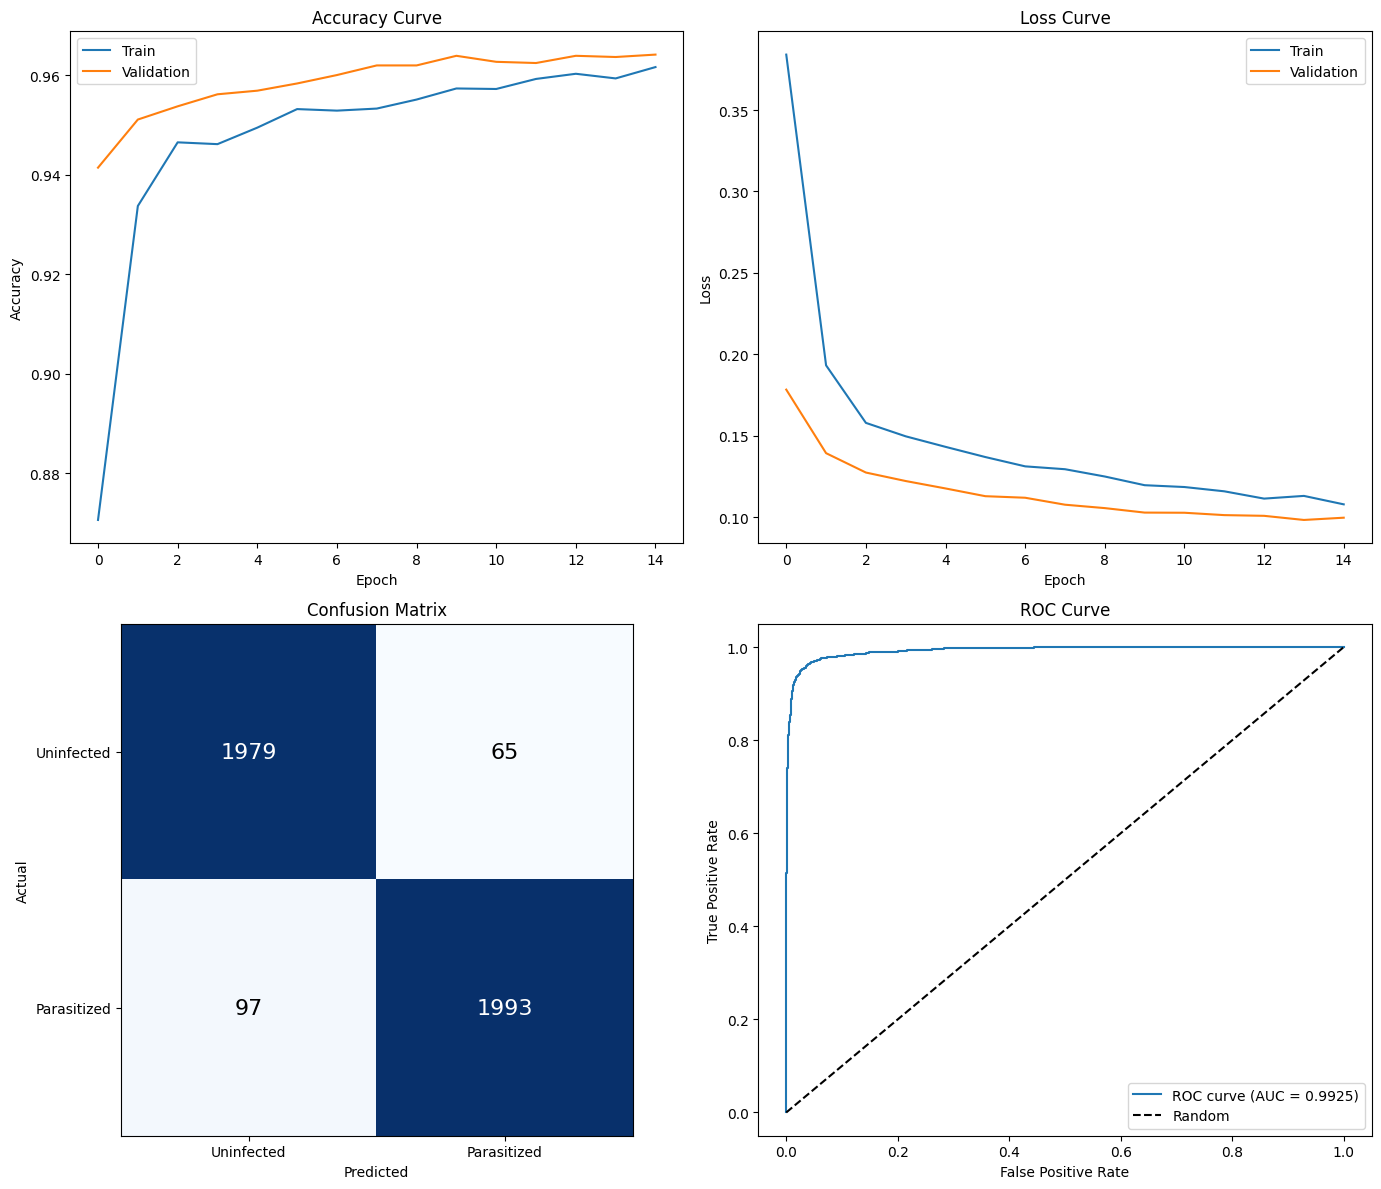

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

axes[0,0].plot(history6.history['accuracy'], label='Train')
axes[0,0].plot(history6.history['val_accuracy'], label='Validation')
axes[0,0].set_title('Accuracy Curve')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()

axes[0,1].plot(history6.history['loss'], label='Train')
axes[0,1].plot(history6.history['val_loss'], label='Validation')
axes[0,1].set_title('Loss Curve')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()

im = axes[1,0].imshow(cm_result, cmap='Blues')
axes[1,0].set_title('Confusion Matrix')
axes[1,0].set_xticks([0,1])
axes[1,0].set_yticks([0,1])
axes[1,0].set_xticklabels(['Uninfected', 'Parasitized'])
axes[1,0].set_yticklabels(['Uninfected', 'Parasitized'])
axes[1,0].set_xlabel('Predicted')
axes[1,0].set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, cm_result[i,j], ha='center', va='center', fontsize=16,
                        color='white' if cm_result[i,j] > cm_result.max()/2 else 'black')

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc_score(fpr, tpr)
axes[1,1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[1,1].plot([0,1], [0,1], 'k--', label='Random')
axes[1,1].set_title('ROC Curve')
axes[1,1].set_xlabel('False Positive Rate')
axes[1,1].set_ylabel('True Positive Rate')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/model6_final_visualizations.png', dpi=150)
plt.show()

## Explainability : Grad-CAM

Grad-CAM heatmaps on one correctly classified infected cell, one correctly classified uninfected cell, and one misclassified example, to see what regions the model is focusing on.

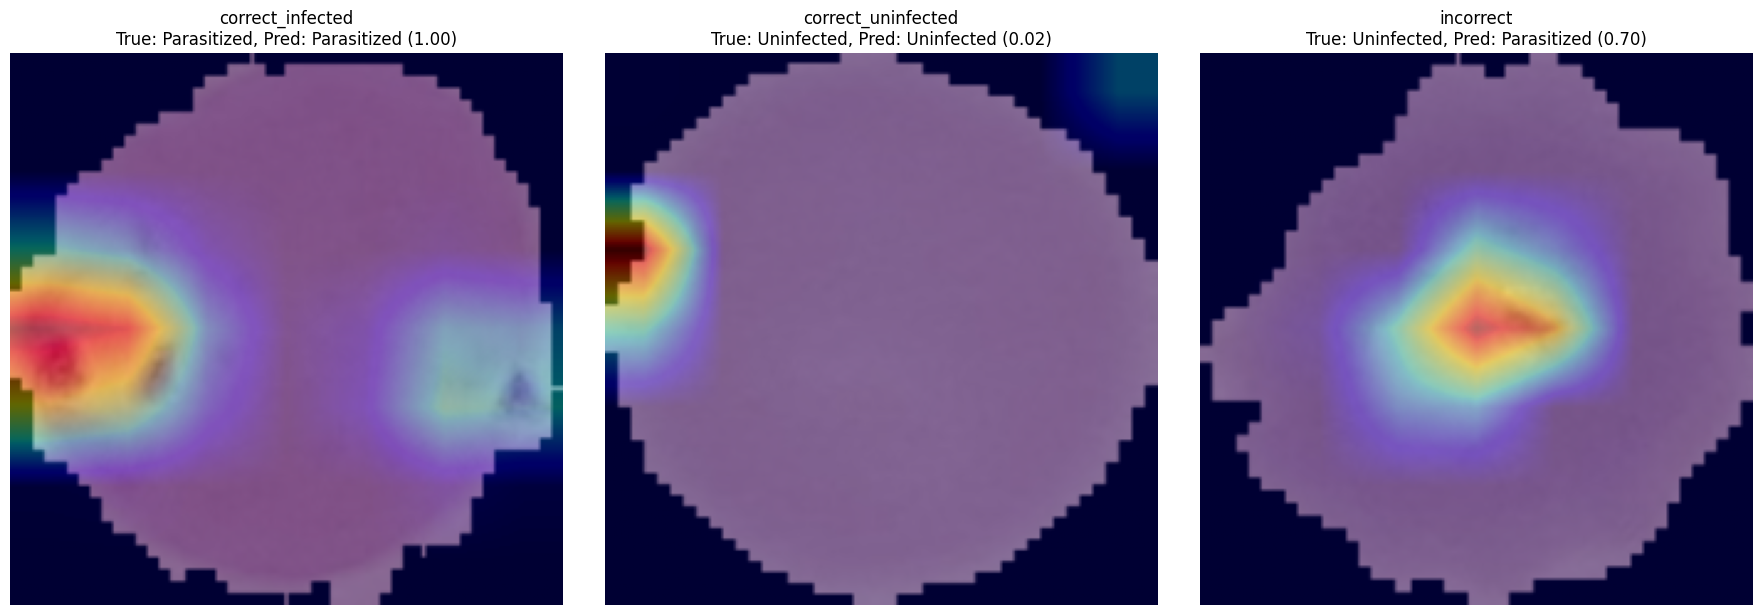

In [25]:
base_m = base_model6
last_conv_layer_name = "top_conv"
dense_layer = model6.layers[-1]

conv_layer_model = models.Model(base_m.input, [base_m.get_layer(last_conv_layer_name).output, base_m.output])

def make_gradcam_heatmap(img, conv_layer_model, dense_layer):
    img_array = tf.expand_dims(img, axis=0)
    preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array)
    with tf.GradientTape() as tape:
        conv_out, base_out = conv_layer_model(preprocessed)
        tape.watch(conv_out)
        pooled = tf.reduce_mean(base_out, axis=(1, 2))
        pred = dense_layer(pooled)
        loss = pred[:, 0]
    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), float(pred[0, 0])

def overlay_heatmap(img, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[:, :, :3]
    overlayed = heatmap_colored * alpha + (img.numpy() / 255.0) * (1 - alpha)
    return overlayed

examples = {'correct_infected': None, 'correct_uninfected': None, 'incorrect': None}

for images, labels in test_ds:
    preds = model6.predict(images, verbose=0).flatten()
    preds_binary = (preds >= 0.5).astype(int)
    labels_np = labels.numpy()
    for i in range(len(labels_np)):
        true_l = labels_np[i]
        pred_l = preds_binary[i]
        if true_l == 1 and pred_l == 1 and examples['correct_infected'] is None:
            examples['correct_infected'] = (images[i], true_l, pred_l, preds[i])
        elif true_l == 0 and pred_l == 0 and examples['correct_uninfected'] is None:
            examples['correct_uninfected'] = (images[i], true_l, pred_l, preds[i])
        elif true_l != pred_l and examples['incorrect'] is None:
            examples['incorrect'] = (images[i], true_l, pred_l, preds[i])
    if all(v is not None for v in examples.values()):
        break

class_names = ['Uninfected', 'Parasitized']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, key in zip(axes, examples.keys()):
    img, true_l, pred_l, prob = examples[key]
    heatmap, _ = make_gradcam_heatmap(img, conv_layer_model, dense_layer)
    overlayed = overlay_heatmap(img, heatmap)
    ax.imshow(overlayed)
    ax.set_title(f"{key}\nTrue: {class_names[true_l]}, Pred: {class_names[pred_l]} ({prob:.2f})")
    ax.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/model6_gradcam.png', dpi=150)
plt.show()

## Error Analysis

Counting false positives/negatives and visually inspecting a sample of misclassified images to look for patterns.

Total misclassified: 162 out of 4134
False positives: 65
False negatives: 97


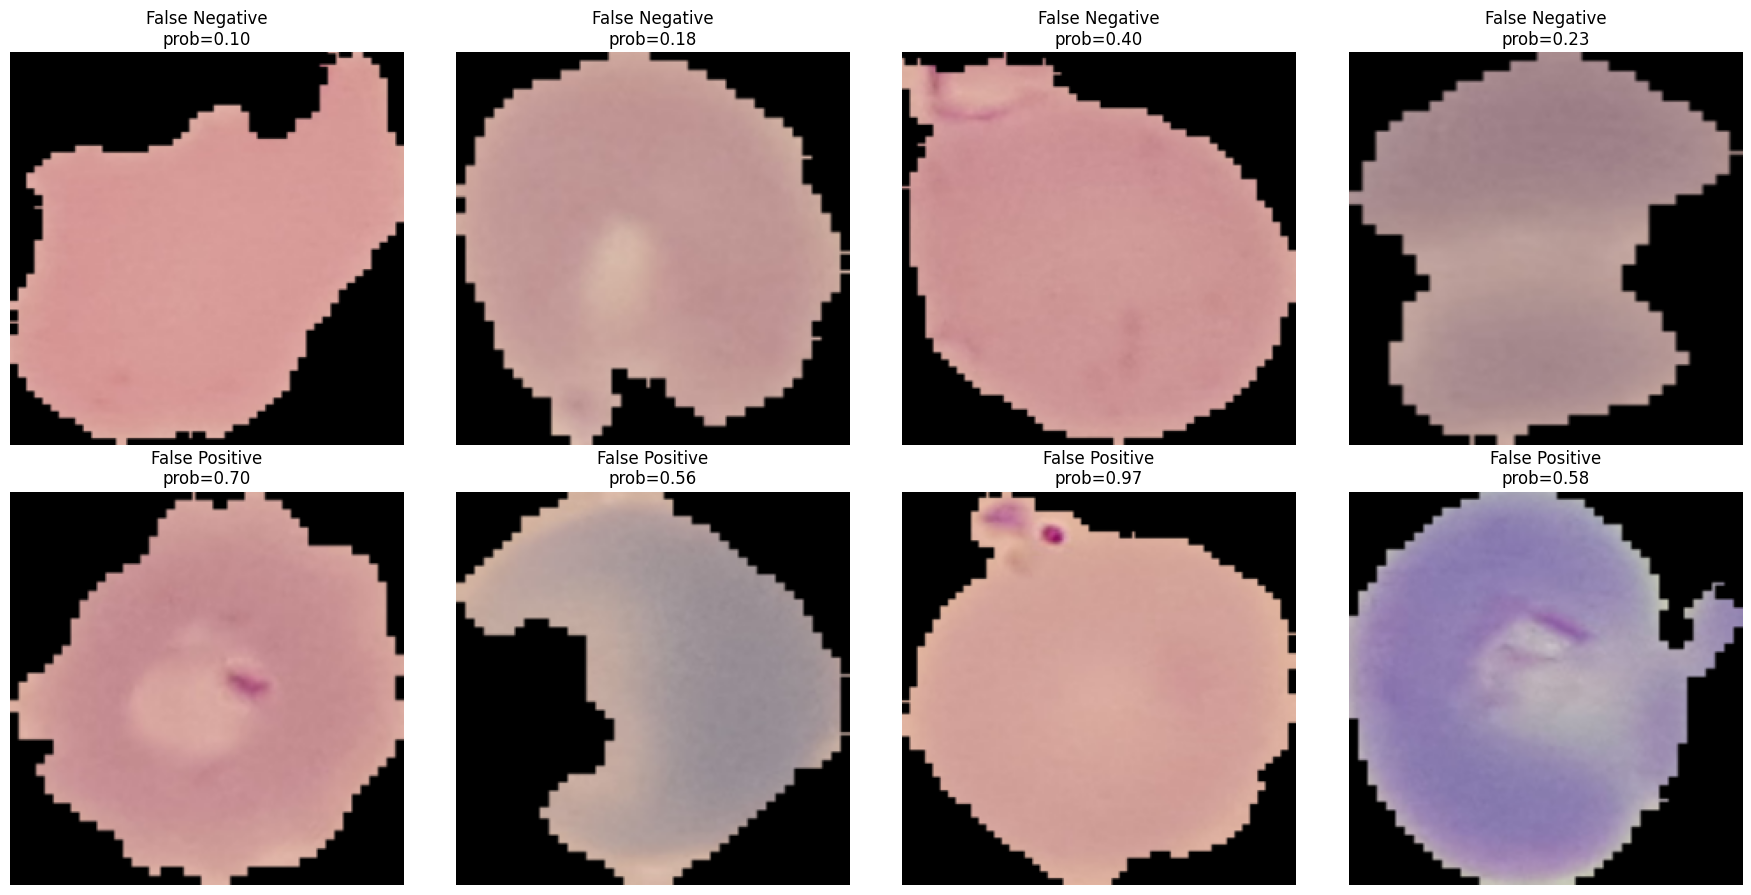

In [26]:
wrong_mask = (y_pred != y_true)
wrong_indices = np.where(wrong_mask)[0]
print(f"Total misclassified: {len(wrong_indices)} out of {len(y_true)}")
print(f"False positives: {np.sum((y_pred==1) & (y_true==0))}")
print(f"False negatives: {np.sum((y_pred==0) & (y_true==1))}")

false_neg_indices = np.where((y_pred==0) & (y_true==1))[0][:4]
false_pos_indices = np.where((y_pred==1) & (y_true==0))[0][:4]

all_test_images = []
for images, labels in test_ds:
    all_test_images.extend(images.numpy())
all_test_images = np.array(all_test_images)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, idx in enumerate(false_neg_indices):
    axes[0, i].imshow(all_test_images[idx].astype('uint8'))
    axes[0, i].set_title(f"False Negative\nprob={y_pred_prob[idx]:.2f}")
    axes[0, i].axis('off')

for i, idx in enumerate(false_pos_indices):
    axes[1, i].imshow(all_test_images[idx].astype('uint8'))
    axes[1, i].set_title(f"False Positive\nprob={y_pred_prob[idx]:.2f}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/model6_error_examples.png', dpi=150)
plt.show()

## Conclusion

Seven experiments were run, isolating one variable each (fine-tuning depth, training duration, optimizer, dropout, batch size). Fine-tuning depth had the largest effect on performance; unfreezing the last 40 layers of EfficientNetB0 (Experiment 6) gave the best result and was selected as the final model.

On the held-out test set, the final model reached 95.45% sensitivity and 96.77% specificity, exceeding the project's target of 95% sensitivity and 90% specificity for transfer-learning models, with an AUC of 0.9934.

Grad-CAM showed the model attending to plausible intracellular regions for correctly classified infected cells. Error analysis showed false negatives tended to involve faint, low-contrast staining, while false positives often involved staining artefacts resembling parasite markers.